### Notebook 18

# **Cross-Validation Convolutional Neural Networks**

This cross-validation (CV) Notebook should be run at least twice, with *cv_iteration = 2* and *cv_iteration = 3*. The results for *cv_iteration = 1* can be obtained from Notebook 6. 

In [41]:
# Define cross-validation iteration. 
cv_iteration = 3

# Define the train set and test set for this iteration. 
if cv_iteration == 1:
    train_set = 'eegfmriNF'
    validation_set = 'eegNF'
    test_set = 'fmriNF'
elif cv_iteration == 2:
    train_set = 'eegNF'
    validation_set = 'fmriNF'
    test_set = 'eegfmriNF'
elif cv_iteration == 3:
    train_set = 'fmriNF'
    validation_set = 'eegfmriNF'
    test_set = 'eegNF'

## **1. Classification**

We define a **convolutional neural network model** for a classification task, using the **Adam optimizer** and the **binary cross-entropy loss function**. 

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pickle
import mne
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import os
import logging

In [43]:
# Define the raw data path. 
raw_data_path = '../../Neuropolis/ds002336-download/'

# Define the preprocessed data path. 
preprocessed_data_path = '../neuropolis-x1_preprocessed_data/'

# Define the results path. 
results_path = '../neuropolis-x1_results/'

In [44]:
# Load the targets and the baseline for the classification task. 
with open(preprocessed_data_path + 'dict_targets.p', 'rb') as file:
    dict_targets = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_targets_classification_sequence.p', 'rb') as file:
    dict_targets_sequence_class = pickle.load(file)
with open(preprocessed_data_path + 'classification/dict_baseline_classification_sequence.p', 'rb') as file:
    dict_baseline_sequence_class = pickle.load(file)

In [45]:
# Define the list of subjects, removing sub-xp102 who has a missing condition. 
subjects = ['sub-xp1' + str(x).zfill(2) for x in range(1, 11)]
subjects.remove('sub-xp102')
subject = subjects[0]

# Retrieve the list of all targets. 
targets = list(dict_targets[subject]['eegfmriNF'].keys())

# Select a sequence length. 
selected_sequence_length = 5

# Retrieve the total number of scans. 
nb_scans_total = dict_targets[subject]['eegfmriNF']['Frontal Pole'].shape[0]

# Define the batch size for the neural networks models. 
batch_size = 32

# Define a dictionary to store the FLOPS for each model. 
dict_flops = dict()

In [46]:
# Define the path of the header file (.vhdr) for an example subject, for the eegfmriNF condition. 
vhdr_path = raw_data_path + 'derivatives/' + subject + '/eeg_pp/' + subject + '_task-eegfmriNF_eeg_pp.vhdr'

# Load the EEG data using the MNE library. 
channels_data = mne.io.read_raw_brainvision(vhdr_path, misc = ['ECG'], preload = True, verbose = False)

/var/folders/8y/sg28phf55jv3mkr_l1g50xn40000gn/T/ipykernel_29995/2277937092.py:5: RuntimeWarning: Not setting position of 1 misc channel found in montage:
['ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  channels_data = mne.io.read_raw_brainvision(vhdr_path, misc = ['ECG'], preload = True, verbose = False)


In [47]:
# Retrieve and display the number of channels. 
nb_channels = len(channels_data.ch_names)
nb_channels

64

In [48]:
# Retrieve and display the sampling frequency. 
sampling_frequency = channels_data.info['sfreq']
sampling_frequency

200.0

In [49]:
# Define the number of scans, and the scan duration in seconds. 
nb_scans = 200
scan_duration = 2

# Compute and display the sampling window, i.e., the number of data points during each scan duration. 
sampling_window = int(scan_duration * sampling_frequency)
sampling_window

400

In [50]:
# Compute and display the sequence window, i.e., the number of data points during each sequence duration (including the current scan). 
sequence_window = (sampling_window * selected_sequence_length) + sampling_window
sequence_window

2400

In [51]:
# Define the dictionaries and the summary DataFrame for storing the features. 
dict_features_basis = dict()
dict_features_sequence_class = dict()
dict_features_sequence_reg = dict()
df_summary_global = pd.DataFrame()

In [52]:
%%capture
# The magic command above hides all outputs from this cell. 

# Iterate through all subjects. 
for subject in subjects:
        
    # Define the subject dictionaries. 
    dict_features_basis[subject] = dict()
    dict_features_sequence_class[subject] = dict()
    dict_features_sequence_reg[subject] = dict()

    # Iterate through all conditions. 
    for condition in ['eegNF', 'fmriNF', 'eegfmriNF']:

        # Skip the current iteration for sub-xp102 and eegNF, since that run is missing. 
        if subject == 'sub-xp102' and condition == 'eegNF':
            continue

        # Load and extract the EEG data in the general features array (2D). Dimensions: data points, channels. 
        vhdr_path = raw_data_path + 'derivatives/' + subject + '/eeg_pp/' + subject + '_task-' + condition + '_eeg_pp.vhdr'
        channels_data = mne.io.read_raw_brainvision(vhdr_path, misc = ['ECG'], preload = True, verbose = False)
        np_channels_data = channels_data.get_data()
        X_basis = np_channels_data.reshape((np_channels_data.shape[1], np_channels_data.shape[0]))

        # Define the particular features array (3D). Dimensions: scans, data points, channels. 
        X_sequence = np.zeros((nb_scans_total - selected_sequence_length, sequence_window, X_basis.shape[1]))
        for scan in range(nb_scans_total - selected_sequence_length):
            X_sequence[scan, :, :] = X_basis[(scan * sampling_window):((scan * sampling_window) + sequence_window), :]

        # Store the features in the dictionaries. 
        dict_features_basis[subject][condition] = X_basis
        dict_features_sequence_class[subject][condition] = X_sequence[1:, :, :]
        dict_features_sequence_reg[subject][condition] = X_sequence

        # Store the shapes of the arrays in the DataFrame. 
        df_summary_global.loc[subject + '/' + condition, 'subject'] = subject
        df_summary_global.loc[subject + '/' + condition, 'condition'] = condition
        df_summary_global.loc[subject + '/' + condition, 'X_basis.shape'] = str(X_basis.shape)
        df_summary_global.loc[subject + '/' + condition, 'dict_features_sequence_class.shape'] = str(X_sequence[1:, :, :].shape)
        df_summary_global.loc[subject + '/' + condition, 'dict_features_sequence_reg.shape'] = str(X_sequence.shape)

# Change the indexes of the DataFrame. 
df_summary_global = df_summary_global.set_index(['subject', 'condition'])

In [53]:
# Display the summary DataFrame. 
df_summary_global

X_basis.shape dict_features_sequence_class.shape  \
subject   condition                                                    
sub-xp101 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp103 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp104 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80400, 64)                    (194, 2400, 64)   
          eegfmriNF   (80400, 64)                    (194, 2400, 64)   
sub-xp105 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp106 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp107 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp108 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp109 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   
sub-xp110 eegNF       (80200, 64)                    (194, 2400, 64)   
          fmriNF      (80200, 64)                    (194, 2400, 64)   
          eegfmriNF   (80200, 64)                    (194, 2400, 64)   

                    dict_features_sequence_reg.shape  
subject   condition                                   
sub-xp101 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp103 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp104 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp105 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp106 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp107 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp108 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp109 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)  
sub-xp110 eegNF                      (195, 2400, 64)  
          fmriNF                     (195, 2400, 64)  
          eegfmriNF                  (195, 2400, 64)

In [54]:
# Define a function to run a convolutional neural network model for a classification task. 
def run_cnn_classification(NeuralNetworkModel, dict_features_sequence, dict_targets_sequence, dict_baseline_sequence):

    # Define the dictionaries and the summary DataFrame. 
    dict_models = dict()
    dict_history = dict()
    dict_predictions = dict()
    df_summary = pd.DataFrame()

    # Iterate through all subjects. 
    for subject in subjects:

        # Display current subject. 
        print(subject)

        # Clone the Neural Network model. 
        PredictorBrain = tf.keras.models.clone_model(NeuralNetworkModel)

        # Retrieve the features of the train set, validation set, and test set. 
        X_tr = dict_features_sequence[subject][train_set]
        X_va = dict_features_sequence[subject][validation_set]
        X_te = dict_features_sequence[subject][test_set]

        # Retrieve the targets of the train set, validation set, and test set. 
        Y_tr = dict_targets_sequence[subject][train_set]
        Y_va = dict_targets_sequence[subject][validation_set]
        Y_te = dict_targets_sequence[subject][test_set]

        # Retrieve the baseline of the train set and determine the baseline accuracy. 
        Baseline = dict_baseline_sequence[subject][train_set]
        accuracy_baseline = np.mean(Baseline == Y_te)

        # Rescale features variables. 
        X_tr_standardized = np.zeros(X_tr.shape)
        X_va_standardized = np.zeros(X_va.shape)
        X_te_standardized = np.zeros(X_te.shape)
        for channel_index in range(nb_channels):
            scaler = StandardScaler()
            X_tr_standardized[:, channel_index, :] = scaler.fit_transform(X_tr[:, channel_index, :])
            X_va_standardized[:, channel_index, :] = scaler.transform(X_va[:, channel_index, :])
            X_te_standardized[:, channel_index, :] = scaler.transform(X_te[:, channel_index, :])

        # End training when accuracy stops improving. 
        early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 6, 
                                                          restore_best_weights = True)

        # Define the loss function, optimizer, and metrics to track during training. 
        PredictorBrain.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001), 
                               loss = 'binary_crossentropy', metrics = ['binary_accuracy'])

        # Fit the model. 
        NeuralNetworkHistory = PredictorBrain.fit(
            x = X_tr_standardized, y = Y_tr,
            validation_data = (X_va_standardized, Y_va), 
            batch_size = batch_size, epochs = 30,
            shuffle = True, callbacks = [early_stopping], verbose = 0
        )

        # Evaluate the test accuracy. 
        (loss_test, accuracy_test) = PredictorBrain.evaluate(X_te_standardized, Y_te, batch_size = batch_size)
        print(f'test loss: {loss_test:.4f}, test accuracy: {accuracy_test:.4f}')

        # Compute the predictions from the neural network. 
        Y_pred = PredictorBrain.predict(X_te_standardized)

        # Convert the probabilities to binary predictions. 
        Y_pred_binary = (Y_pred > 0.5).astype(int)

        # Store the performance metrics and the shapes of the arrays in the DataFrame. 
        df_summary.loc[subject, 'loss_train'] = NeuralNetworkHistory.history['loss'][-1]
        df_summary.loc[subject, 'loss_valid'] = NeuralNetworkHistory.history['val_loss'][-1]
        df_summary.loc[subject, 'loss_test'] = loss_test
        df_summary.loc[subject, 'accuracy_train'] = NeuralNetworkHistory.history['binary_accuracy'][-1]
        df_summary.loc[subject, 'accuracy_valid'] = NeuralNetworkHistory.history['val_binary_accuracy'][-1]
        df_summary.loc[subject, 'accuracy_test'] = accuracy_test
        df_summary.loc[subject, 'accuracy_baseline'] = accuracy_baseline
        df_summary.loc[subject, 'above_baseline'] = str(accuracy_test > accuracy_baseline)
        df_summary.loc[subject, 'X_tr.shape'] = str(X_tr_standardized.shape)
        df_summary.loc[subject, 'X_va.shape'] = str(X_va_standardized.shape)
        df_summary.loc[subject, 'X_te.shape'] = str(X_te_standardized.shape)
        df_summary.loc[subject, 'Y_tr.shape'] = str(Y_tr.shape)
        df_summary.loc[subject, 'Y_va.shape'] = str(Y_va.shape)
        df_summary.loc[subject, 'Y_te.shape'] = str(Y_te.shape)

        # Store the trained model, the model history, and the predictions in the dictionary. 
        dict_models[subject] = PredictorBrain
        dict_history[subject] = NeuralNetworkHistory
        dict_predictions[subject] = Y_pred_binary
    
    return dict_models, dict_history, dict_predictions, df_summary

In [55]:
# Define a function to plot the results of the convolutional neural network training. 
def plot_cnn_classification(dict_history_class, title):
    
    # Display the graph. 
    fig, axes = plt.subplots(nrows = 9, ncols = 2, figsize = (12, 52))
    fig.suptitle(title, fontsize = 14, y = 0.895)
    subject_index = 0

    # Iterate through all subjects. 
    for subject in subjects:

        # Retrieve the history. 
        NeuralNetworkHistory = dict_history_class[subject]

        # Plot loss values. 
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['loss'], label = 'train loss', color = 'blue')
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['val_loss'], label = 'val loss', color = 'green')
        axes[subject_index, 0].set_title(str(subject) + ' valid. loss: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_loss'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 0].set_xlabel('Epoch')
        axes[subject_index, 0].set_ylabel('Loss value')
        axes[subject_index, 0].legend()

        # Plot accuracy values. 
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['binary_accuracy'], label = 'train acc', color = 'blue')
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['val_binary_accuracy'], label = 'val acc', color = 'green')
        axes[subject_index, 1].set_title(str(subject) + ' valid. accuracy: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_binary_accuracy'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 1].set_xlabel('Epoch')
        axes[subject_index, 1].set_ylabel('Accuracy')
        axes[subject_index, 1].legend();

        # Increment. 
        subject_index += 1

In [56]:
# Define the neural network model. 
tf.random.set_seed(0)
NeuralNetworkModel = tf.keras.Sequential()
input_dim = dict_features_sequence_class[subject]['eegfmriNF'].shape[1:]

# Input layer. 
NeuralNetworkModel.add(tf.keras.layers.InputLayer(shape = input_dim))

# 1D convolutional layer. 
NeuralNetworkModel.add(tf.keras.layers.Conv1D(
    filters = 16, 
    kernel_size = 8,
    activation = tf.keras.activations.relu, 
    data_format = 'channels_last'
    ))
NeuralNetworkModel.add(tf.keras.layers.MaxPool1D(data_format = 'channels_last'))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# 1D convolutional layer. 
NeuralNetworkModel.add(tf.keras.layers.Conv1D(
    filters = 32, 
    kernel_size = 8, 
    activation = tf.keras.activations.relu, 
    data_format = 'channels_last'
    ))
NeuralNetworkModel.add(tf.keras.layers.MaxPool1D(data_format = 'channels_last'))
NeuralNetworkModel.add(tf.keras.layers.Flatten(data_format = 'channels_last'))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# Output layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = len(targets), activation = tf.keras.activations.sigmoid,
    kernel_initializer = tf.keras.initializers.VarianceScaling(scale = 1.0, seed = 0)))

# Print network summary. 
NeuralNetworkModel.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 2393, 16)       │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 1196, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1196, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1189, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 594, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 19008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 19008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 49)             │       931,441 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 943,777 (3.60 MB)

 Trainable params: 943,777 (3.60 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Run the convolutional neural network model. 
dict_models_class, dict_history_class, dict_predictions_class, df_summary_class = run_cnn_classification(NeuralNetworkModel, 
                                                                                                         dict_features_sequence_class, 
                                                                                                         dict_targets_sequence_class, 
                                                                                                         dict_baseline_sequence_class)

sub-xp101
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.5028 - loss: 0.6950 
test loss: 0.6956, test accuracy: 0.5037
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
sub-xp103
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.5024 - loss: 0.6935 
test loss: 0.6938, test accuracy: 0.5023
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
sub-xp104
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5048 - loss: 0.6928 
test loss: 0.6936, test accuracy: 0.5032
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-xp105
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.5068 - loss: 0.6921 
test loss: 0.6923, test accuracy: 0.5095
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-xp106
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.4992 - loss: 0.6934 
test loss: 0.6934, test accuracy: 0.5028
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-xp107
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.4966 - loss: 0.6946 
test loss: 0.6943, test accuracy: 0.4953
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9m

In [58]:
# Display the results. 
print('Convolutional Neural Networks: Classification')
df_summary_class

Convolutional Neural Networks: Classification


,loss_train,loss_valid,loss_test,accuracy_train,accuracy_valid,accuracy_test,accuracy_baseline,above_baseline,X_tr.shape,X_va.shape,X_te.shape,Y_tr.shape,Y_va.shape,Y_te.shape
sub-xp101,0.682994,0.719327,0.695632,0.539764,0.511887,0.503682,0.502946,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp103,0.684285,0.706468,0.693780,0.545655,0.498632,0.502314,0.492531,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp104,0.684427,0.698155,0.693567,0.555544,0.516095,0.503156,0.501473,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp105,0.687766,0.697605,0.692311,0.536398,0.501788,0.509468,0.503156,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp106,0.684720,0.701624,0.693397,0.547864,0.510520,0.502840,0.494109,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp107,0.695206,0.699015,0.694346,0.528508,0.500736,0.495266,0.499369,False,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp108,0.688965,0.695842,0.693206,0.539449,0.513255,0.500526,0.496213,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp109,0.687758,0.697758,0.695483,0.533242,0.510414,0.506733,0.494530,True,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"
sub-xp110,0.681725,0.698454,0.695894,0.544919,0.504734,0.500421,0.505996,False,"(194, 2400, 64)","(194, 2400, 64)","(194, 2400, 64)","(194, 49)","(194, 49)","(194, 49)"


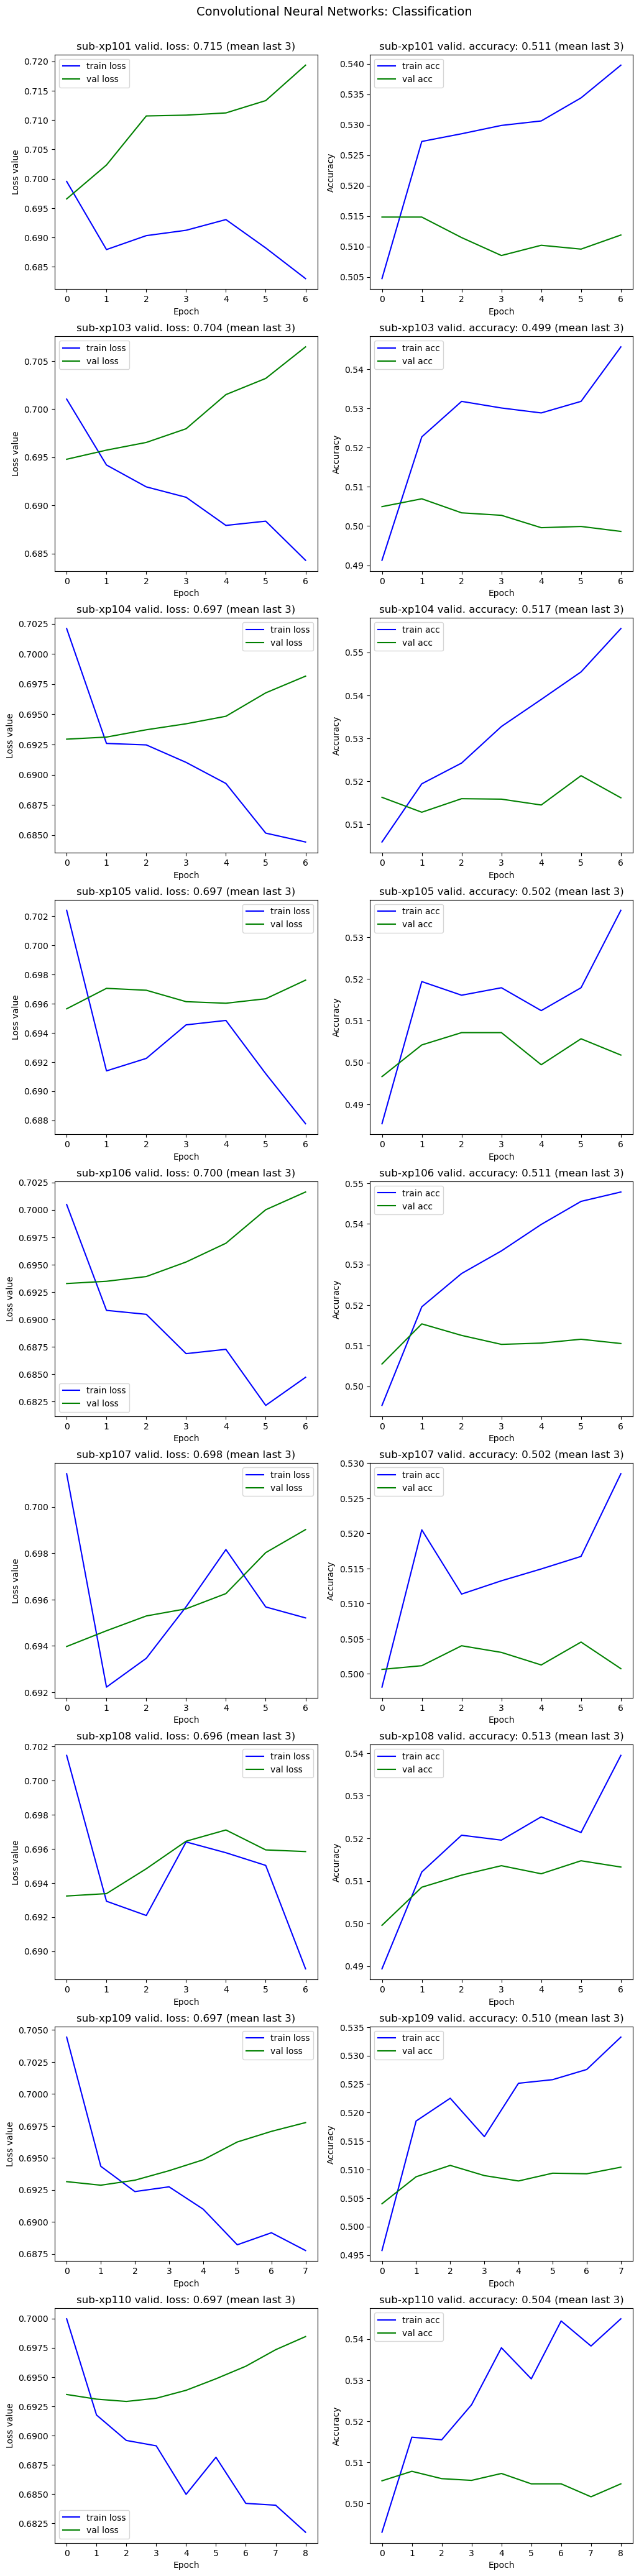

In [59]:
# Display the results. 
plot_cnn_classification(dict_history_class, title = 'Convolutional Neural Networks: Classification')

In [60]:
# Define a function to measure the FLOPs of a model. 
def get_flops(model, input_shape):

    # Retrieve the graph of the concrete function. 
    concrete_func = tf.function(model).get_concrete_function(tf.TensorSpec(input_shape, tf.float32))
    graph = concrete_func.graph

    # Measure the FLOPs. 
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph = graph,
                                          run_meta = run_meta,
                                          cmd = 'op',
                                          options = opts)

    return flops.total_float_ops

In [61]:
# Suppress TensorFlow warnings. 
tf.get_logger().setLevel(logging.ERROR)

# Measure the FLOPs of the model. 
input_shape = (1, *input_dim)  # Batch size = 1. Input dimension is entered with argument unpacking. 
flops = get_flops(NeuralNetworkModel, input_shape)


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

In [62]:
# Store and display the number of FLOPs. 
dict_flops['Convolutional Neural Networks: Classification'] = flops
print('FLOPs per inference:', flops)

FLOPs per inference: 50962657


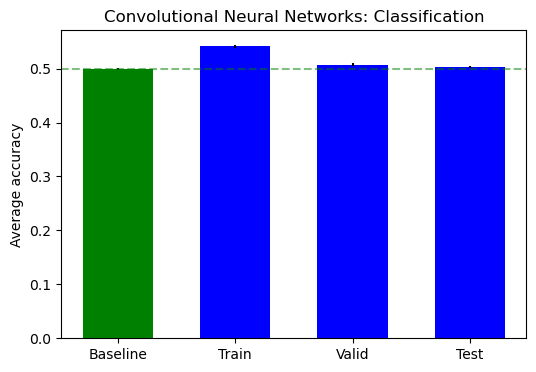

In [63]:
# Retrieve the average accuracy and the standard error of the accuracy. 
acc = [df_summary_class['accuracy_baseline'].mean(), 
       df_summary_class['accuracy_train'].mean(), 
       df_summary_class['accuracy_valid'].mean(), 
       df_summary_class['accuracy_test'].mean()]
acc_se = [np.std(df_summary_class['accuracy_baseline']) / np.sqrt(df_summary_class['accuracy_baseline'].shape[0]), 
          np.std(df_summary_class['accuracy_train']) / np.sqrt(df_summary_class['accuracy_train'].shape[0]), 
          np.std(df_summary_class['accuracy_valid']) / np.sqrt(df_summary_class['accuracy_valid'].shape[0]), 
          np.std(df_summary_class['accuracy_test']) / np.sqrt(df_summary_class['accuracy_test'].shape[0])]

# Display the average accuracy and its standard error in a bar plot. 
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (6, 4))
axes.bar(range(4), acc, width = 0.6, color = ['green', 'blue', 'blue', 'blue'])
axes.errorbar(range(4), acc, yerr = acc_se, fmt = 'None', color = 'black')
axes.axhline(acc[0], 0, 1, color = 'green', linestyle = 'dashed', alpha = 0.5)
axes.set_xticks(range(4), labels = ['Baseline', 'Train', 'Valid', 'Test'])
axes.set_ylabel('Average accuracy')
axes.set_title('Convolutional Neural Networks: Classification');

## **2. Regression**

We define a **convolutional neural network model** for a regression task, using the **Adam optimizer** and the **mean squared error loss function**. 

In [64]:
# Load the targets and the baseline for the regression task. 
with open(preprocessed_data_path + 'regression/dict_targets_regression_sequence.p', 'rb') as file:
    dict_targets_sequence_reg = pickle.load(file)
with open(preprocessed_data_path + 'regression/dict_baseline_regression_sequence.p', 'rb') as file:
    dict_baseline_sequence_reg = pickle.load(file)

In [65]:
# Define the Mean Squared Error function. 
def MSE(y, y_pred):
    return np.mean(np.square(y - y_pred))

In [66]:
# Define the Mean Absolute Error function. 
def MAE(y, y_pred):
    return np.mean(np.abs(y - y_pred))

In [67]:
# Define the Residual Sum of Squares function. 
def RSS(y, y_pred):
    return np.sum(np.square(y - y_pred))

In [68]:
# Define a function to run a convolutional neural network model for a regression task. 
def run_cnn_regression(NeuralNetworkModel, dict_features_sequence, dict_targets_sequence, dict_baseline_sequence):

    # Define the dictionaries and the summary DataFrame. 
    dict_models = dict()
    dict_history = dict()
    dict_predictions = dict()
    df_summary = pd.DataFrame()

    # Iterate through all subjects. 
    for subject in subjects:

        # Display current subject. 
        print(subject)

        # Clone the Neural Network model. 
        PredictorBrain = tf.keras.models.clone_model(NeuralNetworkModel)

        # Retrieve the features of the train set, validation set, and test set. 
        X_tr = dict_features_sequence[subject][train_set]
        X_va = dict_features_sequence[subject][validation_set]
        X_te = dict_features_sequence[subject][test_set]

        # Retrieve the targets of the train set, validation set, and test set. 
        Y_tr = dict_targets_sequence[subject][train_set]
        Y_va = dict_targets_sequence[subject][validation_set]
        Y_te = dict_targets_sequence[subject][test_set]

        # Retrieve the baseline of the train set. 
        Baseline = dict_baseline_sequence[subject][train_set]

        # Rescale features variables. 
        X_tr_standardized = np.zeros(X_tr.shape)
        X_va_standardized = np.zeros(X_va.shape)
        X_te_standardized = np.zeros(X_te.shape)
        for channel_index in range(nb_channels):
            scaler = StandardScaler()
            X_tr_standardized[:, channel_index, :] = scaler.fit_transform(X_tr[:, channel_index, :])
            X_va_standardized[:, channel_index, :] = scaler.transform(X_va[:, channel_index, :])
            X_te_standardized[:, channel_index, :] = scaler.transform(X_te[:, channel_index, :])

        # End training when accuracy stops improving. 
        early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 6, 
                                                          restore_best_weights = True)

        # Define the loss function, optimizer, and metrics to track during training. 
        optimizer = tf.keras.optimizers.Adam(learning_rate = 0.005, beta_1 = 0.9)
        PredictorBrain.compile(optimizer = optimizer, loss = 'mse', metrics = [tf.keras.metrics.MeanAbsoluteError()])

        # Fit the model. 
        NeuralNetworkHistory = PredictorBrain.fit(
            x = X_tr_standardized, y = Y_tr,
            validation_data = (X_va_standardized, Y_va), 
            batch_size = batch_size, epochs = 30, 
            shuffle = True, callbacks = [early_stopping], verbose = 0
        )

        # Evaluate the test MSE and MAE. 
        (mse_test, mae_test) = PredictorBrain.evaluate(X_te_standardized, Y_te, batch_size = batch_size)
        print(f'test MSE: {mse_test:.4f}, test MAE: {mae_test:.4f}')

        # Compute the predictions from the neural network. 
        Y_pred = PredictorBrain.predict(X_te_standardized)

        # Evaluate the performance metrics. 
        mse_baseline = MSE(Y_te, Baseline)
        mae_baseline = MAE(Y_te, Baseline)
        rss_baseline = RSS(Y_te, Baseline)
        mse_model = MSE(Y_te, Y_pred)
        mae_model = MAE(Y_te, Y_pred)
        rss_model = RSS(Y_te, Y_pred)
        r2_model = 1 - (rss_model / rss_baseline)

        # Store the performance metrics and the shapes of the arrays in the DataFrame. 
        df_summary.loc[subject, 'mse_train'] = NeuralNetworkHistory.history['loss'][-1]
        df_summary.loc[subject, 'mse_valid'] = NeuralNetworkHistory.history['val_loss'][-1]
        df_summary.loc[subject, 'mse_test'] = mse_test
        df_summary.loc[subject, 'mae_train'] = NeuralNetworkHistory.history['mean_absolute_error'][-1]
        df_summary.loc[subject, 'mae_valid'] = NeuralNetworkHistory.history['val_mean_absolute_error'][-1]
        df_summary.loc[subject, 'mae_test'] = mae_test
        df_summary.loc[subject, 'mae_baseline'] = mae_baseline
        df_summary.loc[subject, 'r2_model'] = r2_model
        df_summary.loc[subject, 'X_tr.shape'] = str(X_tr_standardized.shape)
        df_summary.loc[subject, 'X_va.shape'] = str(X_va_standardized.shape)
        df_summary.loc[subject, 'X_te.shape'] = str(X_te_standardized.shape)
        df_summary.loc[subject, 'Y_tr.shape'] = str(Y_tr.shape)
        df_summary.loc[subject, 'Y_va.shape'] = str(Y_va.shape)
        df_summary.loc[subject, 'Y_te.shape'] = str(Y_te.shape)

        # Store the trained model, the model history, and the predictions in the dictionary. 
        dict_models[subject] = PredictorBrain
        dict_history[subject] = NeuralNetworkHistory
        dict_predictions[subject] = Y_pred
    
    return dict_models, dict_history, dict_predictions, df_summary

In [69]:
# Define a function to plot the results of the neural network training. 
def plot_cnn_regression(dict_history_reg, title):
    
    # Display the graph. 
    fig, axes = plt.subplots(nrows = 9, ncols = 2, figsize = (12, 52))
    fig.suptitle(title, fontsize = 14, y = 0.895)
    subject_index = 0

    # Iterate through all subjects. 
    for subject in subjects:

        # Retrieve the history. 
        NeuralNetworkHistory = dict_history_reg[subject]

        # Plot MSE values. 
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['loss'], label = 'train MSE', color = 'blue')
        axes[subject_index, 0].plot(NeuralNetworkHistory.history['val_loss'], label = 'val MSE', color = 'green')
        axes[subject_index, 0].set_title(str(subject) + ' valid. MSE: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_loss'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 0].set_xlabel('Epoch')
        axes[subject_index, 0].set_ylabel('MSE')
        axes[subject_index, 0].legend()

        # Plot MAE values. 
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['mean_absolute_error'], label = 'train MAE', color = 'blue')
        axes[subject_index, 1].plot(NeuralNetworkHistory.history['val_mean_absolute_error'], label = 'val MAE', color = 'green')
        axes[subject_index, 1].set_title(str(subject) + ' valid. MAE: {:.3f} (mean last 3)'.format(
            np.mean(NeuralNetworkHistory.history['val_mean_absolute_error'][-3:]) # Take the mean of the last three values. 
        ))
        axes[subject_index, 1].set_xlabel('Epoch')
        axes[subject_index, 1].set_ylabel('MAE')
        axes[subject_index, 1].legend();

        # Increment. 
        subject_index += 1

In [70]:
# Define the neural network model. 
tf.random.set_seed(0)
NeuralNetworkModel = tf.keras.Sequential()
input_dim = dict_features_sequence_reg[subject]['eegfmriNF'].shape[1:]

# Input layer. 
NeuralNetworkModel.add(tf.keras.layers.InputLayer(shape = input_dim))

# 1D convolutional layer. 
NeuralNetworkModel.add(tf.keras.layers.Conv1D(
    filters = 16, 
    kernel_size = 8,
    activation = tf.keras.activations.relu, 
    data_format = 'channels_last'
    ))
NeuralNetworkModel.add(tf.keras.layers.MaxPool1D(data_format = 'channels_last'))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# 1D convolutional layer. 
NeuralNetworkModel.add(tf.keras.layers.Conv1D(
    filters = 32, 
    kernel_size = 8, 
    activation = tf.keras.activations.relu, 
    data_format = 'channels_last'
    ))
NeuralNetworkModel.add(tf.keras.layers.MaxPool1D(data_format = 'channels_last'))
NeuralNetworkModel.add(tf.keras.layers.Flatten(data_format = 'channels_last'))
NeuralNetworkModel.add(tf.keras.layers.Dropout(0.5))

# Output layer. 
NeuralNetworkModel.add(tf.keras.layers.Dense(
    units = dict_targets_sequence_reg[subject]['eegfmriNF'].shape[1], 
    ))

# Print network summary. 
NeuralNetworkModel.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 2393, 16)       │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 1196, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1196, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 1189, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 594, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 19008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 19008)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 49)             │       931,441 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 943,777 (3.60 MB)

 Trainable params: 943,777 (3.60 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
# Run the convolutional neural network model. 
dict_models_reg, dict_history_reg, dict_predictions_reg, df_summary_reg = run_cnn_regression(NeuralNetworkModel, 
                                                                                             dict_features_sequence_reg, 
                                                                                             dict_targets_sequence_reg, 
                                                                                             dict_baseline_sequence_reg)

sub-xp101
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8063 - mean_absolute_error: 0.6932 
test MSE: 0.7356, test MAE: 0.6641
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-xp103
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9449 - mean_absolute_error: 0.7931 
test MSE: 0.8886, test MAE: 0.7633
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
sub-xp104
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7109 - mean_absolute_error: 0.6519 
test MSE: 0.7507, test MAE: 0.6613
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-xp105
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1826 - mean_absolute_error: 0.8662 
test MSE: 0.9735, test MAE: 0.7853
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-xp106
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0651 - mean_absolute_error: 0.8362 
test MSE: 0.9546, test MAE: 0.7923
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
sub-xp107
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0070 - mean_absolute_error: 0.8167 
test MSE: 0.9566, test MAE: 0.7890
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
sub-

In [72]:
# Display the results. 
print('Convolutional Neural Networks: Regression')
df_summary_reg

Convolutional Neural Networks: Regression


,mse_train,mse_valid,mse_test,mae_train,mae_valid,mae_test,mae_baseline,r2_model,X_tr.shape,X_va.shape,X_te.shape,Y_tr.shape,Y_va.shape,Y_te.shape
sub-xp101,0.919899,0.848725,0.735646,0.735644,0.724671,0.664089,0.673287,0.017360,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp103,0.938267,0.964896,0.888637,0.786097,0.800696,0.763260,0.764916,0.002944,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp104,0.890094,0.730302,0.750719,0.756674,0.680598,0.661269,0.664922,0.004904,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp105,0.988584,0.962238,0.973458,0.809180,0.796044,0.785321,0.788727,0.002130,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp106,0.907908,0.939431,0.954631,0.779109,0.783642,0.792328,0.794260,0.005885,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp107,0.967400,0.953681,0.956578,0.801360,0.785922,0.788983,0.783694,-0.008150,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp108,0.985699,0.966219,0.971240,0.814444,0.814525,0.806341,0.808577,0.000612,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp109,0.959842,0.942766,0.968541,0.800478,0.785190,0.813516,0.813239,-0.000726,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"
sub-xp110,0.973831,0.964175,0.958719,0.807512,0.798947,0.788262,0.788212,-0.000046,"(195, 2400, 64)","(195, 2400, 64)","(195, 2400, 64)","(195, 49)","(195, 49)","(195, 49)"


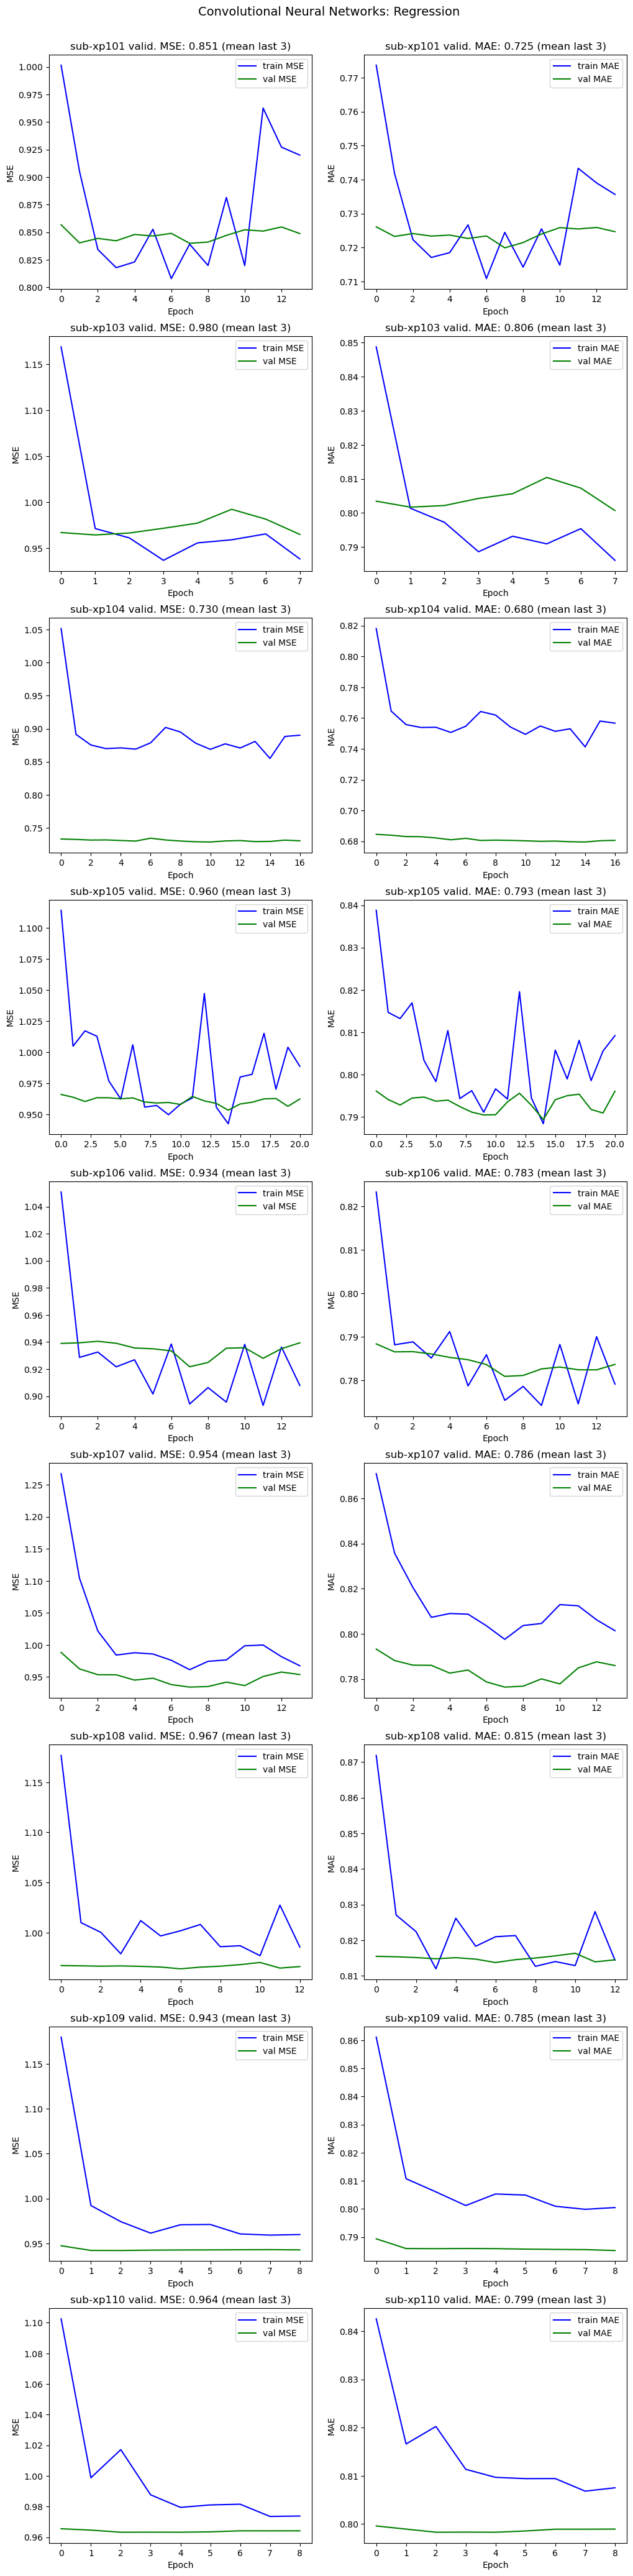

In [73]:
# Display the results. 
plot_cnn_regression(dict_history_reg, title = 'Convolutional Neural Networks: Regression')

In [74]:
# Measure the FLOPs of the model. 
input_shape = (1, *input_dim)  # Batch size = 1. Input dimension is entered with argument unpacking. 
flops = get_flops(NeuralNetworkModel, input_shape)


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

In [75]:
# Store and display the number of FLOPs. 
dict_flops['Convolutional Neural Networks: Regression'] = flops
print('FLOPs per inference:', flops)

FLOPs per inference: 50962657


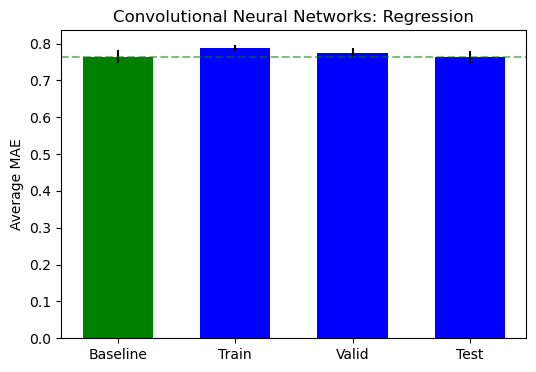

In [76]:
# Retrieve the average MAE and the standard error of the MAE. 
mae = [df_summary_reg['mae_baseline'].mean(), 
       df_summary_reg['mae_train'].mean(), 
       df_summary_reg['mae_valid'].mean(), 
       df_summary_reg['mae_test'].mean()]
mae_se = [np.std(df_summary_reg['mae_baseline']) / np.sqrt(df_summary_reg['mae_baseline'].shape[0]), 
          np.std(df_summary_reg['mae_train']) / np.sqrt(df_summary_reg['mae_train'].shape[0]), 
          np.std(df_summary_reg['mae_valid']) / np.sqrt(df_summary_reg['mae_valid'].shape[0]), 
          np.std(df_summary_reg['mae_test']) / np.sqrt(df_summary_reg['mae_test'].shape[0])]

# Display the average MAE and its standard error in a bar plot. 
fig, axes = plt.subplots(nrows = 1, ncols = 1, figsize = (6, 4))
axes.bar(range(4), mae, width = 0.6, color = ['green', 'blue', 'blue', 'blue'])
axes.errorbar(range(4), mae, yerr = mae_se, fmt = 'None', color = 'black')
axes.axhline(mae[0], 0, 1, color = 'green', linestyle = 'dashed', alpha = 0.5)
axes.set_xticks(range(4), labels = ['Baseline', 'Train', 'Valid', 'Test'])
axes.set_ylabel('Average MAE')
axes.set_title('Convolutional Neural Networks: Regression');

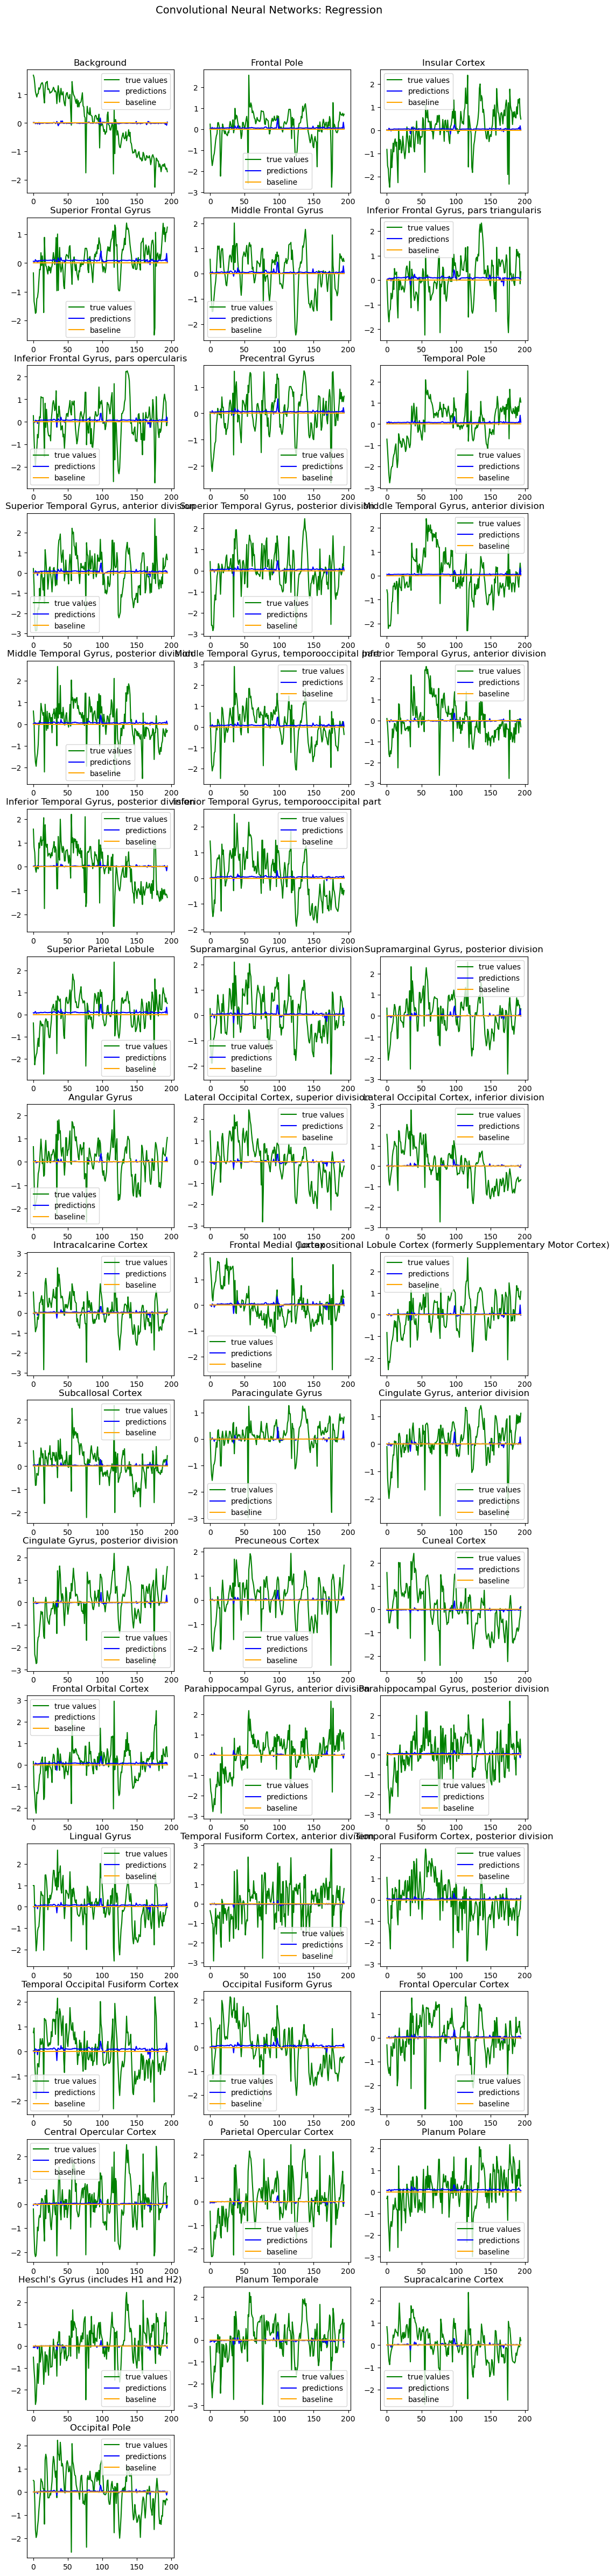

In [77]:
# Select the subject with the best predictions. 
subject = subjects[np.argmax(df_summary_reg['r2_model'])]

# Plot the true values, the predictions, and the baseline for all the targets. 
fig, axes = plt.subplots(nrows = 17, ncols = 3, figsize = (12, 60))
fig.suptitle('Convolutional Neural Networks: Regression', fontsize = 14, y = 0.9)

# Iterate through all brain regions. 
for brain_region_index in range(len(targets)):

    # Retrieve the true values, the predictions, and the baseline for the selected subject and sequence length. 
    Y_te = dict_targets_sequence_reg[subject][test_set][:, brain_region_index]
    Y_pred = dict_predictions_reg[subject][:, brain_region_index]
    Baseline = dict_baseline_sequence_reg[subject][train_set][:, brain_region_index]

    # Compute the row and column indexes. 
    row_index = brain_region_index // 3
    column_index = brain_region_index % 3

    # Plot the true values, the predictions, and the baseline. 
    axes[row_index, column_index].plot(Y_te,  color = 'green', label = 'true values')
    axes[row_index, column_index].plot(Y_pred,  color = 'blue', label = 'predictions')
    axes[row_index, column_index].plot(Baseline,  color = 'orange', label = 'baseline')
    axes[row_index, column_index].legend()
    axes[row_index, column_index].set_title(targets[brain_region_index])

# Hide empty subplots. 
axes[5, 2].set_visible(False)
axes[16, 1].set_visible(False)
axes[16, 2].set_visible(False)

## **3. Results**

In [78]:
# Define the classification cross-validation results path. 
classification_cv_results_path = results_path + 'classification/cross_validation/cv_iteration_' + str(cv_iteration) + '/'

# Define the regression cross-validation results path. 
regression_cv_results_path = results_path + 'regression/cross_validation/cv_iteration_' + str(cv_iteration) + '/'

In [79]:
# Create directories for the results. 
if not os.path.isdir(classification_cv_results_path + 'convolutional_neural_networks/'):
    os.mkdir(classification_cv_results_path + 'convolutional_neural_networks/')
if not os.path.isdir(regression_cv_results_path + 'convolutional_neural_networks/'):
    os.mkdir(regression_cv_results_path + 'convolutional_neural_networks/')

# Save the models in the native Keras format. 
for subject in subjects:
    dict_models_class[subject].save(classification_cv_results_path + 'convolutional_neural_networks/' + subject + '.keras')
    dict_models_reg[subject].save(regression_cv_results_path + 'convolutional_neural_networks/' + subject + '.keras')

# Save the predictions into Pickle files. 
with open(classification_cv_results_path + 'convolutional_neural_networks/dict_predictions_convolutional_neural_networks_class.p', 'wb') as file:
    pickle.dump(dict_predictions_class, file)
with open(regression_cv_results_path + 'convolutional_neural_networks/dict_predictions_convolutional_neural_networks_reg.p', 'wb') as file:
    pickle.dump(dict_predictions_reg, file)

# Save the summaries into Pickle files. 
with open(classification_cv_results_path + 'convolutional_neural_networks/df_summary_convolutional_neural_networks_class.p', 'wb') as file:
    pickle.dump(df_summary_class, file)
with open(regression_cv_results_path + 'convolutional_neural_networks/df_summary_convolutional_neural_networks_reg.p', 'wb') as file:
    pickle.dump(df_summary_reg, file)